In [1]:
import sys
sys.path.insert(0, "../../") 

from image_processing.config import MODEL_WEIGHTS, DEVICE, IMG_SIZE
from image_processing.preprocess import load_image, normalize, preprocess
from image_processing.models import XRayModel
from image_processing.utils import validate_xray, format_output

print("All imports OK")
print(f"Device: {DEVICE}")
print(f"Model weights: {MODEL_WEIGHTS}")


All imports OK
Device: cpu
Model weights: densenet121-res224-all


/Users/grigory/Downloads/LosCoballos/5CCSAGAPLosCaballos/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
img_raw = load_image("../sample_xray.png")
print(f"load_image: shape={img_raw.shape}, dtype={img_raw.dtype}, min={img_raw.min()}, max={img_raw.max()}")
assert img_raw.ndim in (2, 3), "Expected 2D or 3D image"
assert img_raw.max() > 1, "Expected uint8 range [0,255]"
print("load_image PASSED")


load_image: shape=(224, 224), dtype=uint8, min=0, max=253
load_image PASSED


In [3]:
img_norm = normalize(img_raw)
print(f"normalize: min={img_norm.min():.1f}, max={img_norm.max():.1f}, dtype={img_norm.dtype}")
assert img_norm.min() >= -1024, "Min below expected range"
assert img_norm.max() <= 2048, "Max above expected range"
print("normalize PASSED")


normalize: min=-1024.0, max=1007.9, dtype=float32
normalize PASSED


preprocess: shape=torch.Size([1, 1, 224, 224]), dtype=torch.float32


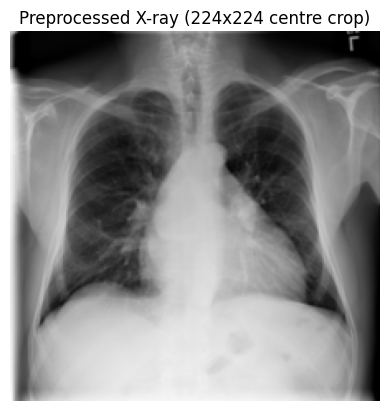

preprocess PASSED


In [4]:
import matplotlib.pyplot as plt

tensor = preprocess(img_raw)
print(f"preprocess: shape={tensor.shape}, dtype={tensor.dtype}")
assert tensor.shape == (1, 1, 224, 224), f"Unexpected shape: {tensor.shape}"

plt.imshow(tensor[0, 0].numpy(), cmap='gray')
plt.title("Preprocessed X-ray (224x224 centre crop)")
plt.axis('off')
plt.show()
print("preprocess PASSED")


In [5]:
import numpy as np

validate_xray(img_raw)
print("validate_xray on real image: PASSED")

try:
    validate_xray(np.zeros((10,)))
    print("FAILED — should have raised")
except ValueError as e:
    print(f"validate_xray correctly raised on 1D input: {e} — PASSED")


validate_xray on real image: PASSED
validate_xray correctly raised on 1D input: Not a valid image: expected 2D or 3D array — PASSED


In [6]:
model = XRayModel()
print(f"Model loaded on: {DEVICE}")
print(f"Pathologies ({len(model.pathologies)}): {model.pathologies}")
assert len(model.pathologies) == 18, "Expected 18 pathologies for densenet121-res224-all"
print("XRayModel load PASSED")


Model loaded on: cpu
Pathologies (18): ['Atelectasis', 'Consolidation', 'Infiltration', 'Pneumothorax', 'Edema', 'Emphysema', 'Fibrosis', 'Effusion', 'Pneumonia', 'Pleural_Thickening', 'Cardiomegaly', 'Nodule', 'Mass', 'Hernia', 'Lung Lesion', 'Fracture', 'Lung Opacity', 'Enlarged Cardiomediastinum']
XRayModel load PASSED


In [7]:
preds = model.predict(tensor)
print("\nPredictions:")
for label, prob in sorted(preds.items(), key=lambda x: -x[1]):
    bar = "█" * int(prob * 20)
    print(f"  {label:<30} {prob:.4f}  {bar}")

assert all(0.0 <= v <= 1.0 for v in preds.values()), "Probabilities out of [0,1]"
print("\nmodel.predict PASSED")



Predictions:
  Cardiomegaly                   0.6207  ████████████
  Fibrosis                       0.5392  ██████████
  Infiltration                   0.5221  ██████████
  Pleural_Thickening             0.5098  ██████████
  Nodule                         0.5092  ██████████
  Atelectasis                    0.5065  ██████████
  Emphysema                      0.5034  ██████████
  Enlarged Cardiomediastinum     0.4470  ████████
  Mass                           0.4137  ████████
  Effusion                       0.3991  ███████
  Lung Opacity                   0.3877  ███████
  Consolidation                  0.3240  ██████
  Pneumothorax                   0.3154  ██████
  Fracture                       0.2935  █████
  Lung Lesion                    0.2307  ████
  Edema                          0.2239  ████
  Pneumonia                      0.1735  ███
  Hernia                         0.0134  

model.predict PASSED


In [8]:
spatial_feats = model.features(tensor)
print(f"Spatial feature map shape: {spatial_feats.shape}")  # (1, 1024, 7, 7)
assert spatial_feats.shape == (1024, 7, 7), "Expected spatial map"
print("Spatial features PASSED")

embedding = spatial_feats.mean(axis=(0, 1)).flatten()
print(f"Derived embedding shape: {embedding.shape}")



Spatial feature map shape: (1024, 7, 7)
Spatial features PASSED
Derived embedding shape: (7,)


In [9]:
formatted = format_output(preds)
assert all(isinstance(v, float) for v in formatted.values()), "Expected floats"
print(f"format_output sample: {list(formatted.items())[:3]}")
print("format_output PASSED")


format_output sample: [('Atelectasis', 0.506501317024231), ('Infiltration', 0.5221112966537476), ('Emphysema', 0.5033750534057617)]
format_output PASSED


In [10]:
img = load_image("../sample_xray.png")
validate_xray(img)
tensor = preprocess(img)
preds = model.predict(tensor)
output = format_output(preds)

print("End-to-end pipeline output:")
print(output)
print("\nEnd-to-end PASSED")


End-to-end pipeline output:
{'Atelectasis': 0.506501317024231, 'Infiltration': 0.5221112966537476, 'Emphysema': 0.5033750534057617, 'Fibrosis': 0.5392019748687744, 'Pleural_Thickening': 0.5097851753234863, 'Cardiomegaly': 0.6206504106521606, 'Nodule': 0.5092154741287231}

End-to-end PASSED


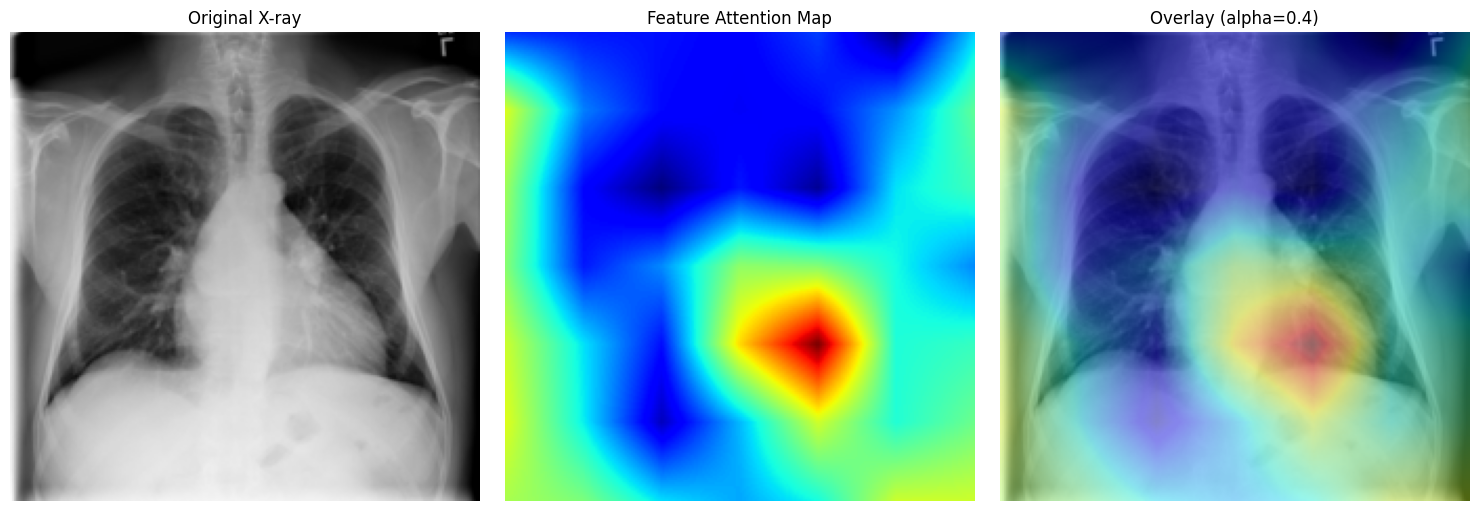

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.ndimage import zoom

img_raw   = load_image('../sample_xray.png')
tensor    = preprocess(img_raw)
feat_map  = model.features(tensor)

attn_7x7 = feat_map.mean(axis=0)
# attn_7x7 = feat_map.max(axis=0)

# Upsample to 224x224
scale = 224 / 7
attn_224 = zoom(attn_7x7, scale, order=1)

# Normalise to [0, 1]
attn_224 = (attn_224 - attn_224.min()) / (attn_224.max() - attn_224.min() + 1e-8)

img_float = img_raw.astype(np.float32) / 255.0
if img_float.ndim == 2:
    img_rgb = np.stack([img_float] * 3, axis=-1)
else:
    img_rgb = img_float

# Apply colourmap to attention
heatmap_rgba = cm.jet(attn_224)
heatmap_rgb  = heatmap_rgba[:, :, :3]

# alpha = heatmap intensity
alpha = 0.4
overlay = (1 - alpha) * img_rgb + alpha * heatmap_rgb
overlay = np.clip(overlay, 0, 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img_rgb, cmap='gray')
axes[0].set_title('Original X-ray')
axes[0].axis('off')

axes[1].imshow(attn_224, cmap='jet')
axes[1].set_title('Feature Attention Map')
axes[1].axis('off')

axes[2].imshow(overlay)
axes[2].set_title('Overlay (alpha=0.4)')
axes[2].axis('off')

plt.tight_layout()
plt.savefig('attention_overlay.png', dpi=150, bbox_inches='tight')
plt.show()


In [12]:
class_idx = 0  
cam = model.generate_cam(spatial_feats, class_idx)
print(f"Single CAM shape: {np.array(cam).shape}")
assert np.array(cam).shape == (224, 224), f"Expected (224,224), got {np.array(cam).shape}"
print(f"CAM stats: min={np.min(cam):.3f}, max={np.max(cam):.3f}")
print("generate_cam() PASSED")

Single CAM shape: (224, 224)
CAM stats: min=-10.865, max=14.216
generate_cam() PASSED


In [13]:
top_cams = model.top_cams(spatial_feats, preds, top_k=5)
print(f"Top-5 CAMs: {list(top_cams.keys())}")
print("top_cams() PASSED")

Top-5 CAMs: ['Cardiomegaly', 'Fibrosis', 'Infiltration', 'Pleural_Thickening', 'Nodule']
top_cams() PASSED
